
# Micro-proyecto1 · Fine-Tuning **ResNet‑50** (Skeleton)
**Autor:** _Tu equipo_  

**Fecha:** 2025-10-27 01:06

> Este cuaderno es un **esqueleto** listo para completar el fine-tuning de **ResNet‑50** sobre un dataset de **MRI cerebrales** en **escala de grises** (4 clases). Cumple principios **SOLID**, **DRY** y una organización inspirada en **Atomic Design**:
- **Átomos**: transformaciones, métricas, pérdidas, optimizadores
- **Moléculas**: dataset y *data loaders*
- **Organismos**: modelo y *trainer*
- **Página/Escena**: `main()` y ciclo de entrenamiento/validación configurable

> **Nota de diseño**: por requerimiento, **no** aplicamos rotaciones inicialmente. Más adelante podrás activarlas para evaluar impacto.


> **Nota de datos (Opción B):** Este cuaderno realiza una partición **estratificada 80/10/10** de `./data_set` **sin mover archivos**. Usamos `ImageFolder` como raíz (clases por carpeta), obtenemos índices con **StratifiedShuffleSplit** y construimos **Subsets** con transforms por split para `train`, `val` y `test`. De esta forma, el **pipeline** de preprocesamiento queda contenido, reproducible (semillas) y sin duplicar datos ni lógica.

## 1. Librerías

In [1]:
# Todas las importaciones en un solo lugar (principio: alta cohesión, separación de intereses)
from __future__ import annotations
import os
import math
import time
import copy
import random
from dataclasses import dataclass, asdict
from typing import Callable, Dict, List, Optional, Tuple

import numpy as np
import torch
import json
from torch import nn, optim
from torch.optim import Optimizer
from torch.optim.lr_scheduler import OneCycleLR, ReduceLROnPlateau
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.model_selection import StratifiedShuffleSplit  # <-- estratificación 80/10/10

# Opcional: para LR Finder (visualización)
import matplotlib.pyplot as plt



## 2. Hiperparámetros (todas las "perillas" en un solo sitio)
> Ajusta desde aquí todo lo relevante: rutas, *batch size*, *learning rate*, *scheduler*, *augmentations*, etc.


In [2]:
# ---- Safe runtime for low /dev/shm environments ----
import torch, gc
try:
    torch.multiprocessing.set_sharing_strategy("file_system")
except Exception:
    pass

# Limpieza de memoria (GPU/CPU)
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()


0

In [3]:
# Instalación de la librería kaggle (solo la primera vez)
#!pip install kaggle -q

# Configurar credenciales de Kaggle
#!mkdir -p ~/.kaggle
#!mv kaggle.json ~/.kaggle/
#!chmod 600 ~/.kaggle/kaggle.json

# Crear carpeta destino para el dataset
#!mkdir -p data_set

# Descargar y descomprimir el dataset desde Kaggle
#!kaggle datasets download -d rm1000/brain-tumor-mri-scans -p data_set --unzip

# Confirmar descarga
#print("✅ Descarga completa. Archivos ubicados en data_set/")
#!ls data_set

#!find data_set -type d -name ".ipynb_checkpoints" -exec rm -rf {} +
#!ls -la data_set




In [4]:
@dataclass
class Config:
    # --- Rutas ---
    data_dir: str = "./data_set"      # raíz plana con subcarpetas por clase (ImageFolder)
    out_dir: str = "./outputs"
    run_name: str = "resnet50_grayscale_ft"
    # --- Datos ---
    img_size: int = 224
    num_classes: int = 4
    input_mode: str = "replicate_to_3"  # 'replicate_to_3' | 'single_channel_conv'
    # --- Splits (Opción B: estratificados sin mover archivos) ---
    val_split: float = 0.10
    test_split: float = 0.10
    use_stratified_splits: bool = True
    sampler_seed: int = 42
    # --- Entrenamiento ---
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    epochs: int = 20
    batch_size: int = 32
    base_lr: float = 1e-05
    weight_decay: float = 1e-4
    momentum: float = 0.9
    optimizer_name: str = "adamw"  # 'adamw' | 'sgd'
    # --- Scheduler ---
    scheduler_name: str = "reduce_on_plateau"  # 'one_cycle' | 'reduce_on_plateau' | 'none'
    one_cycle_max_lr: float = 1e-3
    plateau_factor: float = 0.5
    plateau_patience: int = 2
    # --- Early Stopping ---
    early_stopping_patience: int = 5
    # --- DataLoader ---
    num_workers: int = 4
    pin_memory: bool = True

cfg = Config()
print("Config:", asdict(cfg))


Config: {'data_dir': './data_set', 'out_dir': './outputs', 'run_name': 'resnet50_grayscale_ft', 'img_size': 224, 'num_classes': 4, 'input_mode': 'replicate_to_3', 'val_split': 0.1, 'test_split': 0.1, 'use_stratified_splits': True, 'sampler_seed': 42, 'seed': 42, 'device': 'cuda', 'epochs': 20, 'batch_size': 32, 'base_lr': 1e-05, 'weight_decay': 0.0001, 'momentum': 0.9, 'optimizer_name': 'adamw', 'scheduler_name': 'reduce_on_plateau', 'one_cycle_max_lr': 0.001, 'plateau_factor': 0.5, 'plateau_patience': 2, 'early_stopping_patience': 5, 'num_workers': 4, 'pin_memory': True}


## 3. Utilidades: semilla y helpers

In [5]:

def set_seed(seed: int) -> None:
    """Fija todas las semillas relevantes para reproducibilidad."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(cfg.seed)
os.makedirs(cfg.out_dir, exist_ok=True)



## 4. Átomos: **Transforms** (sin rotaciones por ahora)
> Mantener el preprocesamiento y *augmentations* con mínima sorpresa.  
> **No** se aplican rotaciones inicialmente (requisito).


In [6]:

class GrayTo3Channels(nn.Module):
    """Convierte tensores [1,H,W] a [3,H,W] replicando el canal gris (DRY: reutilizable)."""
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() == 3 and x.size(0) == 1:
            return x.repeat(3, 1, 1)
        return x

def build_transforms(cfg: Config) -> Tuple[transforms.Compose, transforms.Compose]:
    """Crea transforms de train/valid según 'input_mode'. Sin rotaciones por ahora."""
    common = [
        transforms.Grayscale(num_output_channels=1),  # Asegura 1 canal de entrada
        transforms.Resize((cfg.img_size, cfg.img_size)),
        # Augmentations leves (sin rotación): flips horizontales opcionales y jitter moderado
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.1, contrast=0.1)  # prudente en MRI
    ]
    to_tensor = [transforms.ToTensor()]

    if cfg.input_mode == "replicate_to_3":
        post = [GrayTo3Channels(), transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.25,0.25,0.25])]
    else:  # 'single_channel_conv'
        post = [transforms.Normalize(mean=[0.5], std=[0.25])]

    train_tfms = transforms.Compose(common + to_tensor + post)
    valid_tfms = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((cfg.img_size, cfg.img_size)),
        transforms.ToTensor()
    ] + ( [GrayTo3Channels(), transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.25,0.25,0.25])] if cfg.input_mode == "replicate_to_3"
          else [transforms.Normalize(mean=[0.5], std=[0.25])] ))
    return train_tfms, valid_tfms



## 5. Moléculas: **Dataset/DataModule**
- Se usa `ImageFolder` (estructura `root/class_x/*.jpg`).
- Si no tienes split, puedes duplicar el directorio y dejar `train/` y `val/` o, alternativamente, hacer un **split aleatorio**.


In [7]:
class DataModule:
    """Carga de datos con **splits estratificados 80/10/10** sin mover archivos.
    - Usa un único ImageFolder raíz para obtener 'samples' y 'targets'.
    - Crea índices con StratifiedShuffleSplit.
    - Construye tres Subsets con transforms por split: train/val/test.
    """
    def __init__(self, cfg: Config):
        self.cfg = cfg
        self.class_to_idx = None
        self.idx_to_class = None
        self.train_tfms, self.valid_tfms = build_transforms(cfg)

    def _collect_targets(self):
        base = datasets.ImageFolder(self.cfg.data_dir)  # sin transforms, solo para metadata
        y = base.targets  # lista de enteros
        self.class_to_idx = base.class_to_idx
        self.idx_to_class = {v: k for k, v in self.class_to_idx.items()}
        return base, y

    def setup(self) -> None:
        base, y = self._collect_targets()
        n_total = len(y)
        # Paso 1: test 10%
        sss1 = StratifiedShuffleSplit(n_splits=1, test_size=self.cfg.test_split, random_state=self.cfg.sampler_seed)
        all_idx = np.arange(n_total)
        trainval_idx, test_idx = next(sss1.split(all_idx, y))

        # Paso 2: val del remanente, tamaño proporcional para alcanzar 10% del total
        val_portion = self.cfg.val_split / (1.0 - self.cfg.test_split)
        y_trainval = [y[i] for i in trainval_idx]
        sss2 = StratifiedShuffleSplit(n_splits=1, test_size=val_portion, random_state=self.cfg.sampler_seed)
        train_idx_rel, val_idx_rel = next(sss2.split(trainval_idx, y_trainval))
        train_idx = trainval_idx[train_idx_rel]
        val_idx   = trainval_idx[val_idx_rel]

        # DataSets base con transforms por split
        train_base = datasets.ImageFolder(self.cfg.data_dir, transform=self.train_tfms)
        val_base   = datasets.ImageFolder(self.cfg.data_dir, transform=self.valid_tfms)
        test_base  = datasets.ImageFolder(self.cfg.data_dir, transform=self.valid_tfms)

        # Subsets por índices
        train_ds = torch.utils.data.Subset(train_base, train_idx.tolist())
        val_ds   = torch.utils.data.Subset(val_base,   val_idx.tolist())
        test_ds  = torch.utils.data.Subset(test_base,  test_idx.tolist())

        # Loaders
        self.train_loader = DataLoader(
            train_ds, batch_size=self.cfg.batch_size, shuffle=True,
            num_workers=self.cfg.num_workers, pin_memory=self.cfg.pin_memory
        )
        self.val_loader = DataLoader(
            val_ds, batch_size=self.cfg.batch_size, shuffle=False,
            num_workers=self.cfg.num_workers, pin_memory=self.cfg.pin_memory
        )
        self.test_loader = DataLoader(
            test_ds, batch_size=self.cfg.batch_size, shuffle=False,
            num_workers=self.cfg.num_workers, pin_memory=self.cfg.pin_memory
        )

    def loaders(self) -> Tuple[DataLoader, DataLoader, DataLoader]:
        return self.train_loader, self.val_loader, self.test_loader



## 6. Organismos: **Modelo (ResNet‑50)**
**Grayscale:** dos opciones equivalentes funcionalmente:
1) **Replicar** canal gris → 3 canales (no modifica pesos originales).  
2) **Modificar** `conv1` para aceptar `in_channels=1` (promediar pesos preentrenados en RGB).

> Por defecto dejamos `replicate_to_3` (más simple y menos propenso a errores); puedes cambiar a `single_channel_conv` en `cfg`.


In [8]:

def adapt_first_conv_to_single_channel(model: nn.Module) -> nn.Module:
    """Convierte conv1 de ResNet-50 para aceptar 1 canal, promediando pesos RGB preentrenados."""
    conv1 = model.conv1
    if conv1.in_channels == 1:
        return model  # ya adaptado
    w = conv1.weight.data
    w_mean = w.mean(dim=1, keepdim=True)  # [64,1,7,7]
    new_conv1 = nn.Conv2d(
        in_channels=1, out_channels=conv1.out_channels,
        kernel_size=conv1.kernel_size, stride=conv1.stride,
        padding=conv1.padding, bias=conv1.bias is not None
    )
    with torch.no_grad():
        new_conv1.weight = nn.Parameter(w_mean)
        if conv1.bias is not None:
            new_conv1.bias = conv1.bias
    model.conv1 = new_conv1
    return model

class ModelBuilder:
    """Crea el modelo y su cabeza de clasificación (OCP: abierta a extensión)."""
    def __init__(self, cfg: Config):
        self.cfg = cfg

    def build(self) -> nn.Module:
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        if self.cfg.input_mode == "single_channel_conv":
            model = adapt_first_conv_to_single_channel(model)

        # Reemplazar la cabeza (fc) por una capa para 4 clases
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, self.cfg.num_classes)
        return model



## 7. Átomos: **Pérdida, Métricas, Optimizador y Scheduler**
- Métrica primaria sugerida: **macro-F1** (útil ante desbalance).
- Implementamos `accuracy` y `macro_f1` básicos sin dependencias externas.


In [9]:

def criterion_fn() -> nn.Module:
    return nn.CrossEntropyLoss()

def accuracy(y_true: torch.Tensor, y_pred: torch.Tensor) -> float:
    preds = y_pred.argmax(dim=1)
    return (preds == y_true).float().mean().item()

def macro_f1(y_true: torch.Tensor, y_pred: torch.Tensor, num_classes: int) -> float:
    preds = y_pred.argmax(dim=1)
    f1_scores = []
    for c in range(num_classes):
        tp = ((preds == c) & (y_true == c)).sum().item()
        fp = ((preds == c) & (y_true != c)).sum().item()
        fn = ((preds != c) & (y_true == c)).sum().item()
        if tp + fp == 0 or tp + fn == 0:
            f1_scores.append(0.0)
        else:
            precision = tp / (tp + fp + 1e-12)
            recall    = tp / (tp + fn + 1e-12)
            if precision + recall == 0:
                f1_scores.append(0.0)
            else:
                f1_scores.append(2 * precision * recall / (precision + recall))
    return float(np.mean(f1_scores))

def build_optimizer(model: nn.Module, cfg: Config) -> Optimizer:
    if cfg.optimizer_name.lower() == "sgd":
        return optim.SGD(model.parameters(), lr=cfg.base_lr, momentum=cfg.momentum, weight_decay=cfg.weight_decay)
    else:
        return optim.AdamW(model.parameters(), lr=cfg.base_lr, weight_decay=cfg.weight_decay)

def build_scheduler(optimizer: Optimizer, cfg: Config, steps_per_epoch: Optional[int] = None):
    if cfg.scheduler_name == "one_cycle":
        assert steps_per_epoch is not None, "OneCycleLR requiere steps_per_epoch"
        return OneCycleLR(optimizer, max_lr=cfg.one_cycle_max_lr,
                          epochs=cfg.epochs, steps_per_epoch=steps_per_epoch)
    elif cfg.scheduler_name == "reduce_on_plateau":
        return ReduceLROnPlateau(optimizer, mode='max', factor=cfg.plateau_factor,
                                 patience=cfg.plateau_patience, verbose=True)
    else:
        return None



## 8. **LR Finder** (opcional, recomendado)
**Buena práctica** para elegir *learning rate*: ejecutar un **LR Range Test** (Leslie Smith).  
Procedimiento:
1. Fija el modelo en modo entrenamiento y comienza con un LR muy bajo (p.ej. `1e-7`).  
2. Incrementa el LR exponencialmente cada iteración hasta un valor alto (p.ej. `1`).  
3. Registra pérdida vs. LR (log-scale).  
4. Elige un valor en la región **antes** de que la pérdida comience a dispararse (o el valle de pérdida si es claro).

Alternativas/Complementos:
- **OneCycleLR** con `max_lr` elegido desde el LR Finder.  
- Mini *grid search* de LR en un **subset** del entrenamiento (rápido).

> Este bloque implementa el LR Range Test; úsalo con un *subset* para hacerlo ágil.


In [10]:

@torch.no_grad()
def plot_lr_finder(lrs: List[float], losses: List[float]) -> None:
    plt.figure()
    plt.plot(lrs, losses)
    plt.xscale('log')
    plt.xlabel('Learning Rate (log scale)')
    plt.ylabel('Loss')
    plt.title('LR Range Test')
    plt.show()

def lr_range_test(model: nn.Module, dataloader: DataLoader, cfg: Config,
                  start_lr: float = 1e-7, end_lr: float = 1.0, num_iters: int = 200) -> Tuple[List[float], List[float]]:
    model = copy.deepcopy(model).to(cfg.device)
    model.train()
    criterion = criterion_fn()
    optimizer = optim.AdamW(model.parameters(), lr=start_lr, weight_decay=cfg.weight_decay)

    lrs, losses = [], []
    lr_mult = (end_lr / start_lr) ** (1 / max(1, num_iters-1))
    lr = start_lr
    best_loss = float('inf')
    i = 0

    for images, targets in dataloader:
        images, targets = images.to(cfg.device), targets.to(cfg.device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        lrs.append(lr)
        losses.append(loss.item())

        # update LR
        lr *= lr_mult
        for g in optimizer.param_groups:
            g['lr'] = lr

        i += 1
        if i >= num_iters or lr > end_lr or loss.item() > 4 * best_loss:
            break
        best_loss = min(best_loss, loss.item())
    return lrs, losses



## 9. Organismos: **Trainer** (entrenamiento/validación, early stopping, checkpoints)
> Diseñado con SRP y extensión simple para *callbacks*.


In [11]:

class Trainer:
    def __init__(self, cfg: Config):
        self.cfg = cfg
        self.best_score = -float('inf')
        self.no_improve_epochs = 0
        self.history = {'train_loss':[], 'val_loss':[], 'val_acc':[], 'val_f1':[]}

    def train_one_epoch(self, model, loader, criterion, optimizer):
        model.train()
        running_loss = 0.0
        for images, targets in loader:
            images, targets = images.to(self.cfg.device), targets.to(self.cfg.device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        return running_loss / len(loader.dataset)

    @torch.no_grad()
    def validate(self, model, loader, criterion):
        model.eval()
        running_loss = 0.0
        all_preds, all_targets = [], []
        for images, targets in loader:
            images, targets = images.to(self.cfg.device), targets.to(self.cfg.device)
            outputs = model(images)
            loss = criterion(outputs, targets)
            running_loss += loss.item() * images.size(0)
            all_preds.append(outputs.cpu())
            all_targets.append(targets.cpu())
        all_preds = torch.cat(all_preds, dim=0)
        all_targets = torch.cat(all_targets, dim=0)
        val_loss = running_loss / len(loader.dataset)
        val_acc = accuracy(all_targets, all_preds)
        val_f1  = macro_f1(all_targets, all_preds, self.cfg.num_classes)
        return val_loss, val_acc, val_f1

    def fit(self, model, train_loader, val_loader):
        model = model.to(self.cfg.device)
        criterion = criterion_fn()
        optimizer = build_optimizer(model, self.cfg)

        steps_per_epoch = len(train_loader)
        scheduler = build_scheduler(optimizer, self.cfg, steps_per_epoch=steps_per_epoch)

        best_weights = copy.deepcopy(model.state_dict())
        for epoch in range(self.cfg.epochs):
            train_loss = self.train_one_epoch(model, train_loader, criterion, optimizer)
            val_loss, val_acc, val_f1 = self.validate(model, val_loader, criterion)

            if isinstance(scheduler, OneCycleLR):
                scheduler.step()
            elif isinstance(scheduler, ReduceLROnPlateau):
                scheduler.step(val_f1)

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            self.history['val_f1'].append(val_f1)

            print(f"Epoch {epoch+1:03d}/{self.cfg.epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f}")

            # Early stopping por macro-F1
            if val_f1 > self.best_score:
                self.best_score = val_f1
                best_weights = copy.deepcopy(model.state_dict())
                self.no_improve_epochs = 0
                torch.save(best_weights, os.path.join(self.cfg.out_dir, f"{self.cfg.run_name}_best.pth"))
            else:
                self.no_improve_epochs += 1
                if self.no_improve_epochs >= self.cfg.early_stopping_patience:
                    print("Early stopping activado.")
                    break
        model.load_state_dict(best_weights)
        return model, self.history



## 10. **Main** (orquestación)
> No se ejecuta por defecto. Completa `cfg.data_dir` y descomenta para correr.


In [12]:
def main(cfg: Config):
    dm = DataModule(cfg)
    dm.setup()
    train_loader, val_loader, test_loader = dm.loaders()

    builder = ModelBuilder(cfg)
    model = builder.build()

    # --- LR Finder (opcional) ---
    # subset_loader = torch.utils.data.DataLoader(
    #     torch.utils.data.Subset(train_loader.dataset, indices=range(0, min(512, len(train_loader.dataset)))),
    #     batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, pin_memory=cfg.pin_memory
    # )
    # lrs, losses = lr_range_test(model, subset_loader, cfg, start_lr=1e-6, end_lr=5e-2, num_iters=150)
    # plot_lr_finder(lrs, losses)
    # cfg.base_lr = 1e-3  # ajustar según el gráfico

    trainer = Trainer(cfg)
    model, history = trainer.fit(model, train_loader, val_loader)

    # Evaluación final en TEST con el mejor checkpoint cargado por Trainer
    criterion = criterion_fn()
    test_loss, test_acc, test_f1 = trainer.validate(model, test_loader, criterion)
    print(f"TEST | loss={test_loss:.4f} | acc={test_acc:.4f} | macro_f1={test_f1:.4f}")

    # Guardar historia y métricas de test
    os.makedirs(cfg.out_dir, exist_ok=True)
    np.save(os.path.join(cfg.out_dir, f"{cfg.run_name}_history.npy"), history, allow_pickle=True)
    with open(os.path.join(cfg.out_dir, f"{cfg.run_name}_test_metrics.json"), "w") as f:
        f.write(json.dumps({"loss": test_loss, "acc": test_acc, "macro_f1": test_f1}, indent=2))

In [13]:
# ---- Safe training settings for DataLoader / memory ----
# Reduce concurrencia y evita memoria compartida en el loader
cfg.num_workers = 0          # clave: sin multiproceso
cfg.pin_memory = False       # clave: sin page-locked
cfg.batch_size = min(cfg.batch_size, 16)  # baja batch                 si hace falta

# (Opcional) si aún falla, prueba con batch de 8:
# cfg.batch_size = 8

In [14]:
main(cfg)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 407MB/s]


Epoch 001/20 | train_loss=0.8132 | val_loss=0.3681 | val_acc=0.8890 | val_f1=0.8833
Epoch 002/20 | train_loss=0.2960 | val_loss=0.1996 | val_acc=0.9303 | val_f1=0.9266
Epoch 003/20 | train_loss=0.1750 | val_loss=0.1371 | val_acc=0.9545 | val_f1=0.9525
Epoch 004/20 | train_loss=0.1149 | val_loss=0.1200 | val_acc=0.9744 | val_f1=0.9731
Epoch 005/20 | train_loss=0.0785 | val_loss=0.0672 | val_acc=0.9787 | val_f1=0.9775
Epoch 006/20 | train_loss=0.0608 | val_loss=0.0638 | val_acc=0.9829 | val_f1=0.9819
Epoch 007/20 | train_loss=0.0410 | val_loss=0.0456 | val_acc=0.9858 | val_f1=0.9849
Epoch 008/20 | train_loss=0.0281 | val_loss=0.0526 | val_acc=0.9844 | val_f1=0.9836
Epoch 009/20 | train_loss=0.0292 | val_loss=0.0541 | val_acc=0.9844 | val_f1=0.9834
Epoch 00010: reducing learning rate of group 0 to 5.0000e-06.
Epoch 010/20 | train_loss=0.0196 | val_loss=0.0720 | val_acc=0.9801 | val_f1=0.9791
Epoch 011/20 | train_loss=0.0196 | val_loss=0.0579 | val_acc=0.9829 | val_f1=0.9821
Epoch 012/20 |

NameError: name 'json' is not defined

In [15]:
# =========================================
# 🛠️ Re-evaluar TEST y guardar métricas (sin reentrenar)
# =========================================
import os, json, torch

# 1) Cargar loaders
dm = DataModule(cfg)
dm.setup()
_, _, test_loader = dm.loaders()

# 2) Reconstruir modelo y cargar el mejor checkpoint
builder = ModelBuilder(cfg)
model = builder.build().to(cfg.device)

best_path = os.path.join(cfg.out_dir, f"{cfg.run_name}_best.pth")
assert os.path.isfile(best_path), f"No existe el checkpoint: {best_path}"
state = torch.load(best_path, map_location=cfg.device)
model.load_state_dict(state)

# 3) Validar en TEST
trainer = Trainer(cfg)
criterion = criterion_fn()
test_loss, test_acc, test_f1 = trainer.validate(model, test_loader, criterion)
print(f"TEST (re-eval) | loss={test_loss:.4f} | acc={test_acc:.4f} | macro_f1={test_f1:.4f}")

# 4) Guardar JSON de métricas
os.makedirs(cfg.out_dir, exist_ok=True)
with open(os.path.join(cfg.out_dir, f"{cfg.run_name}_test_metrics.json"), "w") as f:
    json.dump({"loss": float(test_loss), "acc": float(test_acc), "macro_f1": float(test_f1)}, f, indent=2)

print("✅ Métricas de test guardadas en", os.path.join(cfg.out_dir, f"{cfg.run_name}_test_metrics.json"))


TEST (re-eval) | loss=0.0192 | acc=0.9929 | macro_f1=0.9927
✅ Métricas de test guardadas en ./outputs/resnet50_grayscale_ft_test_metrics.json


In [16]:
import numpy as np, os
hist_path = os.path.join(cfg.out_dir, f"{cfg.run_name}_history.npy")
assert os.path.isfile(hist_path), f"No existe {hist_path}"
history = np.load(hist_path, allow_pickle=True).item()
print("Claves en history:", list(history.keys()))
print("Últimos valores:", {k: history[k][-1] for k in history})


Claves en history: ['train_loss', 'val_loss', 'val_acc', 'val_f1']
Últimos valores: {'train_loss': 0.007104541819797322, 'val_loss': 0.043983349293254446, 'val_acc': 0.9871976971626282, 'val_f1': 0.9866224772974677}



## 11. Recomendación sobre **Learning Rate**
- Ejecuta el **LR Range Test** en un **subset** (p.ej., 512 muestras, 100–200 iteraciones).
- Elige un LR en la **zona estable** antes del disparo de la pérdida (o cerca del mínimo).  
- Para entrenamiento completo, dos alternativas robustas:
  1. **OneCycleLR** con `max_lr` elegido del LR Finder (con *warm-up* implícito y decay).  
  2. **ReduceLROnPlateau** monitorizando **macro-F1** (descender LR cuando no mejore).

> Como regla práctica inicial: `1e-3` con **AdamW** o `3e-2` con **SGD+momentum** suele ser buen punto de partida para fine-tuning de ResNet‑50 en 224×224; **afina** tras el LR Finder.

## 12. **Grayscale** y cambios en ResNet‑50
- **Opción A (por defecto):** *replicar* el canal gris a 3 → **no** modificas la arquitectura preentrenada y mantienes pesos RGB intactos.  
- **Opción B:** *modificar* `conv1` para `in_channels=1`, promediando pesos RGB. Equivale a aprender un filtro inicial específico para escala de grises.  
Ambas son válidas; mantenemos **A** por simplicidad y compatibilidad, con posibilidad de cambiar a **B** desde `cfg.input_mode`.



---
### Qué sigue
1. Validar `cfg.data_dir` y la estructura del dataset.  
2. (Opcional) Correr **LR Finder** y ajustar `cfg.base_lr` o `one_cycle_max_lr`.  
3. Ejecutar `main(cfg)` y revisar métricas/curvas.  
4. Añadir matriz de confusión y gráficos para el informe (máx. 2 páginas).

> Este esqueleto prioriza SRP/SOLID, con módulos **reusables** y **extensibles**, evitando duplicación (**DRY**) y con una jerarquía clara (**Atomic Design**).


“Análisis del experimento (post-training)”

In [17]:
# ============================================
# Análisis post-entrenamiento: preds & probas
# ============================================
import os, json, numpy as np, torch
from sklearn.metrics import classification_report
import torch.nn.functional as F

# 1) Cargar DataModule y TEST loader (sin multiproceso por seguridad)
dm = DataModule(cfg)
dm.setup()
_, _, test_loader = dm.loaders()
idx_to_class = dm.idx_to_class
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

# 2) Cargar mejor checkpoint
builder = ModelBuilder(cfg)
model = builder.build().to(cfg.device)
best_ckpt = os.path.join(cfg.out_dir, f"{cfg.run_name}_best.pth")
state = torch.load(best_ckpt, map_location=cfg.device)
model.load_state_dict(state)
model.eval()

# 3) Pasada por TEST para recolectar logits, preds y etiquetas
all_logits, all_targets = [], []
with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(cfg.device)
        logits = model(images)
        all_logits.append(logits.cpu())
        all_targets.append(targets)

logits = torch.cat(all_logits, dim=0)            # [N, C]
y_true = torch.cat(all_targets, dim=0).numpy()   # [N]
y_proba = F.softmax(logits, dim=1).numpy()       # [N, C]
y_pred = logits.argmax(dim=1).numpy()            # [N]

# 4) Guardar artefactos para análisis repetible
os.makedirs(os.path.join(cfg.out_dir, "analysis"), exist_ok=True)
np.save(os.path.join(cfg.out_dir, "analysis", "y_true.npy"), y_true)
np.save(os.path.join(cfg.out_dir, "analysis", "y_pred.npy"), y_pred)
np.save(os.path.join(cfg.out_dir, "analysis", "y_proba.npy"), y_proba)

# 5) Resumen por clase en consola
print("Clases:", class_names)
print("\nClassification Report (macro avg al final):\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


Clases: ['glioma', 'healthy', 'meningioma', 'pituitary']

Classification Report (macro avg al final):

              precision    recall  f1-score   support

      glioma     1.0000    0.9877    0.9938       162
     healthy     1.0000    0.9950    0.9975       200
  meningioma     0.9879    0.9879    0.9879       165
   pituitary     0.9832    1.0000    0.9915       176

    accuracy                         0.9929       703
   macro avg     0.9928    0.9926    0.9927       703
weighted avg     0.9930    0.9929    0.9929       703



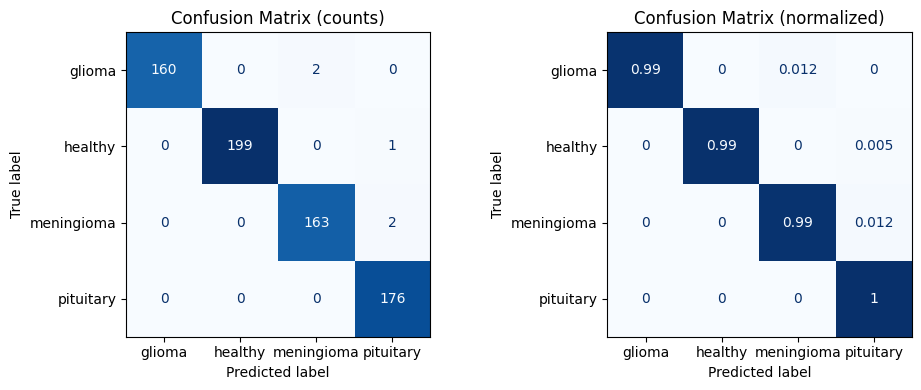

✅ Guardado: ./outputs/analysis/confusion_matrices.png


In [18]:
# ============================================
# Matriz de confusión (conteos y normalizada)
# ============================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

analysis_dir = os.path.join(cfg.out_dir, "analysis")
y_true = np.load(os.path.join(analysis_dir, "y_true.npy"))
y_pred = np.load(os.path.join(analysis_dir, "y_pred.npy"))

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
cm_norm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))), normalize='true')

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax[0], colorbar=False, cmap="Blues")
ax[0].set_title("Confusion Matrix (counts)")
ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(ax=ax[1], colorbar=False, cmap="Blues")
ax[1].set_title("Confusion Matrix (normalized)")
plt.tight_layout()
cm_path = os.path.join(analysis_dir, "confusion_matrices.png")
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado:", cm_path)


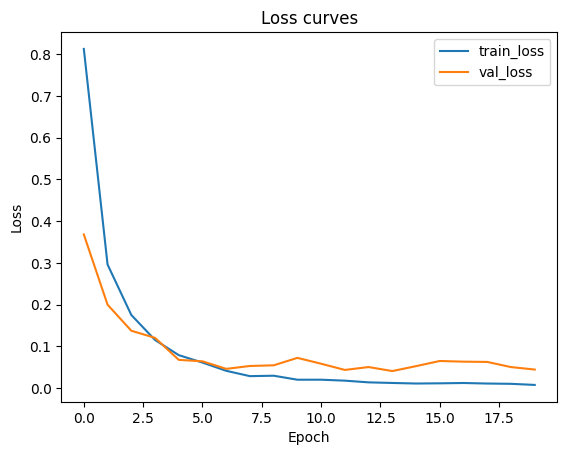

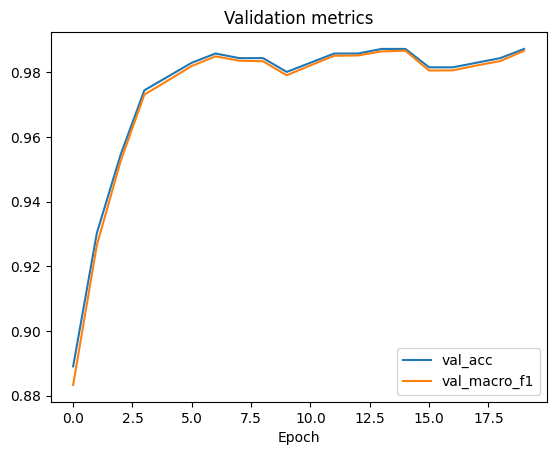

✅ Guardados: ./outputs/analysis/curves_loss.png y ./outputs/analysis/curves_val_metrics.png


In [19]:
# ============================================
# Curvas de entrenamiento (loss / métricas)
# ============================================
import numpy as np, matplotlib.pyplot as plt, os

hist_path = os.path.join(cfg.out_dir, f"{cfg.run_name}_history.npy")
history = np.load(hist_path, allow_pickle=True).item()

# Pérdida
plt.figure()
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.title("Loss curves")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
p1 = os.path.join(cfg.out_dir, "analysis", "curves_loss.png")
plt.savefig(p1, dpi=150, bbox_inches="tight"); plt.show()

# Métricas val
plt.figure()
if "val_acc" in history: plt.plot(history["val_acc"], label="val_acc")
if "val_f1"  in history: plt.plot(history["val_f1"],  label="val_macro_f1")
plt.title("Validation metrics")
plt.xlabel("Epoch"); plt.legend()
p2 = os.path.join(cfg.out_dir, "analysis", "curves_val_metrics.png")
plt.savefig(p2, dpi=150, bbox_inches="tight"); plt.show()

print("✅ Guardados:", p1, "y", p2)


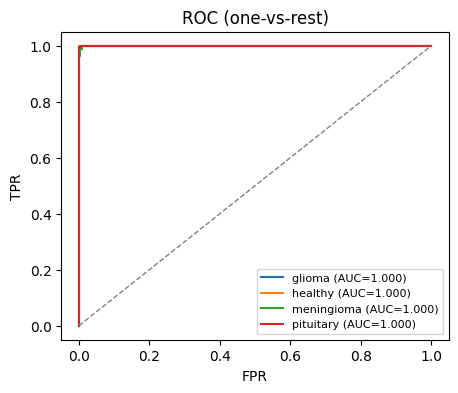

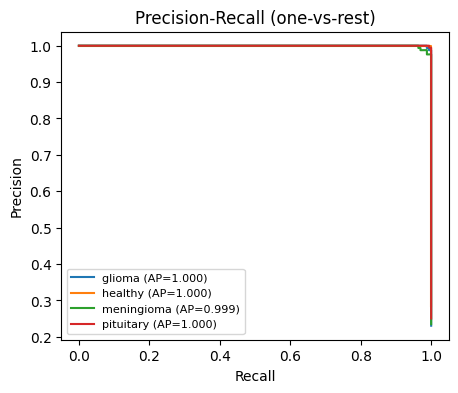

✅ Guardados: ./outputs/analysis/roc_multiclass.png y ./outputs/analysis/pr_multiclass.png


In [20]:
# ============================================
# ROC y Precision-Recall por clase (OvR)
# ============================================
import numpy as np, matplotlib.pyplot as plt, os
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from itertools import cycle

analysis_dir = os.path.join(cfg.out_dir, "analysis")
y_true = np.load(os.path.join(analysis_dir, "y_true.npy"))
y_proba = np.load(os.path.join(analysis_dir, "y_proba.npy"))

n_classes = len(class_names)
# binarizar etiquetas
Y = np.zeros((y_true.shape[0], n_classes), dtype=int)
Y[np.arange(y_true.shape[0]), y_true] = 1

# ROC
plt.figure(figsize=(5,4))
for i, cname in enumerate(class_names):
    fpr, tpr, _ = roc_curve(Y[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cname} (AUC={roc_auc:.3f})")
plt.plot([0,1], [0,1], '--', lw=1, color='gray')
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC (one-vs-rest)")
plt.legend(fontsize=8)
roc_path = os.path.join(analysis_dir, "roc_multiclass.png")
plt.savefig(roc_path, dpi=150, bbox_inches="tight"); plt.show()

# PR
plt.figure(figsize=(5,4))
for i, cname in enumerate(class_names):
    prec, rec, _ = precision_recall_curve(Y[:, i], y_proba[:, i])
    ap = average_precision_score(Y[:, i], y_proba[:, i])
    plt.plot(rec, prec, label=f"{cname} (AP={ap:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall (one-vs-rest)")
plt.legend(fontsize=8)
pr_path = os.path.join(analysis_dir, "pr_multiclass.png")
plt.savefig(pr_path, dpi=150, bbox_inches="tight"); plt.show()

print("✅ Guardados:", roc_path, "y", pr_path)


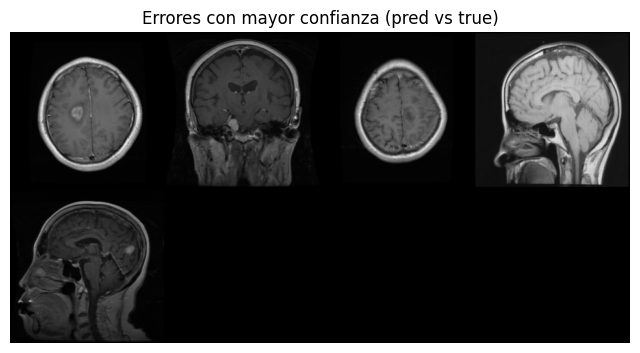

✅ Guardado: ./outputs/analysis/top_confident_errors.png


In [21]:
# ============================================
# Errores de mayor confianza (hard negatives)
# ============================================
import numpy as np, matplotlib.pyplot as plt, os
from torchvision.utils import make_grid

analysis_dir = os.path.join(cfg.out_dir, "analysis")
y_true = np.load(os.path.join(analysis_dir, "y_true.npy"))
y_pred = np.load(os.path.join(analysis_dir, "y_pred.npy"))
y_proba = np.load(os.path.join(analysis_dir, "y_proba.npy"))

# Confianza de la clase predicha
conf = y_proba[np.arange(len(y_pred)), y_pred]

# Índices de errores ordenados por mayor confianza en la clase equivocada
wrong = np.where(y_pred != y_true)[0]
if len(wrong) == 0:
    print("🎉 No hay errores en test.")
else:
    worst = wrong[np.argsort(conf[wrong])[::-1]][:16]

    # construir un loader indexado para visualizar
    # reusar test_loader.dataset (Subset(ImageFolder))
    subset = test_loader.dataset
    imgs = []
    for idx in worst:
        img, _ = subset[idx]        # transform aplicada
        imgs.append(img)

    grid = make_grid(imgs, nrow=4, normalize=True)
    plt.figure(figsize=(8,8))
    plt.imshow(np.transpose(grid.numpy(), (1,2,0)))
    plt.axis("off")
    plt.title("Errores con mayor confianza (pred vs true)")
    err_path = os.path.join(analysis_dir, "top_confident_errors.png")
    plt.savefig(err_path, dpi=150, bbox_inches="tight"); plt.show()
    print("✅ Guardado:", err_path)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


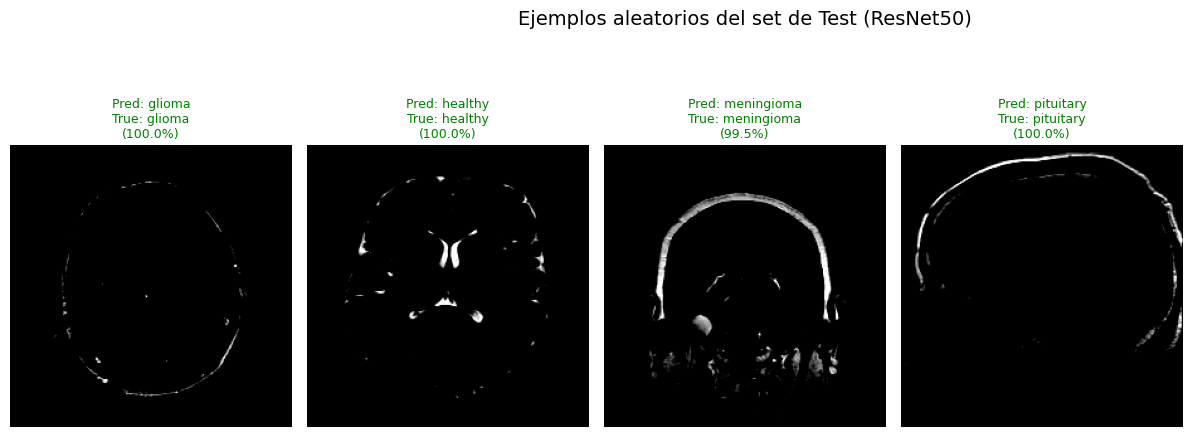

✅ Muestra guardada en: ./outputs/analysis/random_test_examples.png


In [22]:
# ============================================================
# 🎯 Ejemplos aleatorios del set de test (pred vs real)
# ============================================================
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# Reutilizar análisis ya guardado
analysis_dir = os.path.join(cfg.out_dir, "analysis")
y_true = np.load(os.path.join(analysis_dir, "y_true.npy"))
y_pred = np.load(os.path.join(analysis_dir, "y_pred.npy"))
y_proba = np.load(os.path.join(analysis_dir, "y_proba.npy"))

# Dataset del test (Subset dentro del DataModule)
dm = DataModule(cfg)
dm.setup()
_, _, test_loader = dm.loaders()
test_dataset = test_loader.dataset
idx_to_class = dm.idx_to_class

# Seleccionar 5 índices aleatorios del test
#sample_idxs = random.sample(range(len(y_true)), 5)
sample_idxs = []
for c in range(len(idx_to_class)):
    idxs_c = np.where(y_true == c)[0]
    if len(idxs_c) > 0:
        sample_idxs.append(random.choice(idxs_c))


plt.figure(figsize=(15, 5))
for i, idx in enumerate(sample_idxs):
    img, _ = test_dataset[idx]
    pred_idx = y_pred[idx]
    true_idx = y_true[idx]
    conf = float(np.max(y_proba[idx])) * 100

    pred_label = idx_to_class[pred_idx]
    true_label = idx_to_class[true_idx]

    # Mostrar imagen
    plt.subplot(1, 5, i + 1)
    img_disp = img.permute(1, 2, 0).numpy()
    plt.imshow(img_disp, cmap="gray")
    plt.axis("off")

    # Color verde si acierta, rojo si falla
    color = "green" if pred_label == true_label else "red"
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}\n({conf:.1f}%)", color=color, fontsize=9)

plt.suptitle("Ejemplos aleatorios del set de Test (ResNet50)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.92])
rand_ex_path = os.path.join(analysis_dir, "random_test_examples.png")
plt.savefig(rand_ex_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"✅ Muestra guardada en: {rand_ex_path}")


<Figure size 1500x700 with 0 Axes>

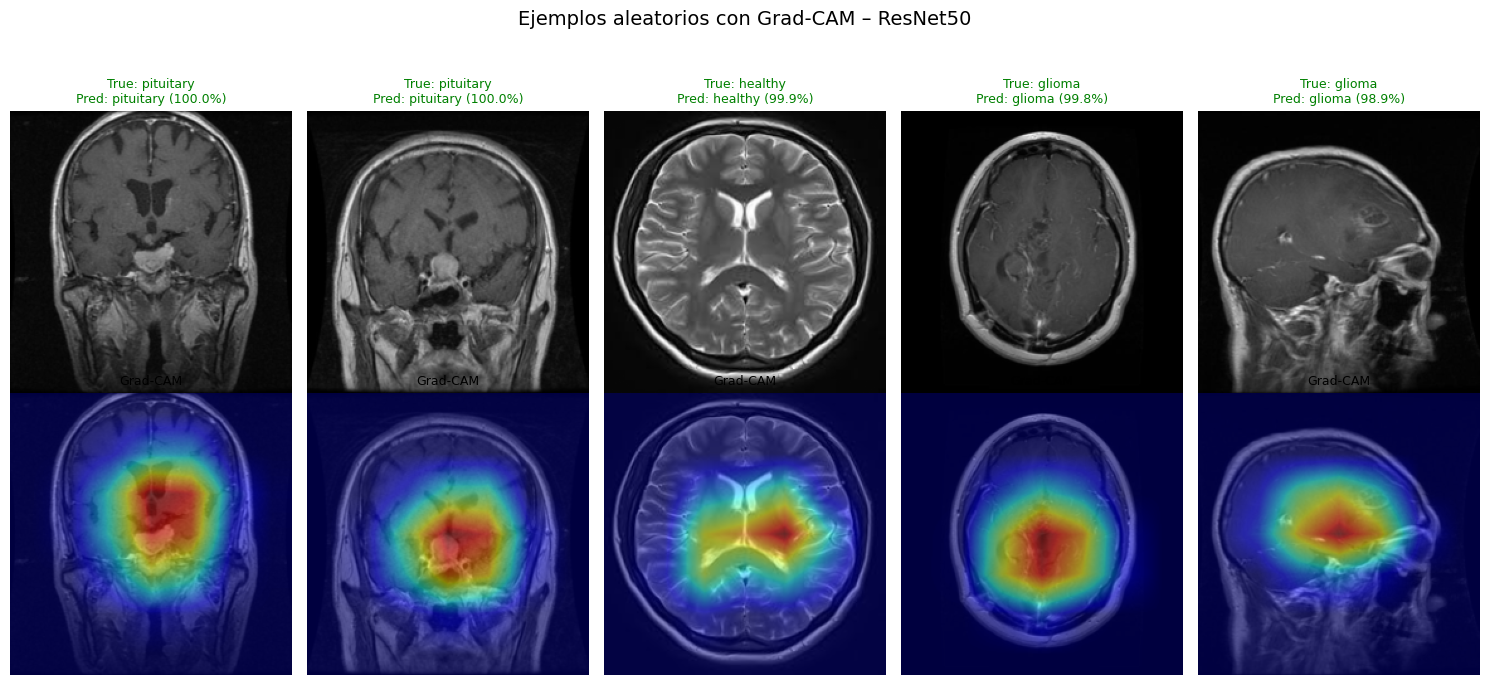

✅ Grad-CAM guardado en: ./outputs/analysis/random_test_gradcam.png


In [24]:
# ============================================================
# 🔥 Ejemplos aleatorios con mapas Grad-CAM (ResNet50) – FIX
# ============================================================
import os, random, numpy as np, matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# --- Preparar dataset y modelo (usa tu cfg/run actuales) ---
dm = DataModule(cfg)
dm.setup()
_, _, test_loader = dm.loaders()
test_dataset = test_loader.dataset
idx_to_class = dm.idx_to_class
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

builder = ModelBuilder(cfg)
model = builder.build().to(cfg.device)
state = torch.load(os.path.join(cfg.out_dir, f"{cfg.run_name}_best.pth"), map_location=cfg.device)
model.load_state_dict(state)
model.eval()

# --- Hooks para activar Grad-CAM en la última capa conv de ResNet50 ---
# Para ResNet50 (Bottleneck), la última conv del último bloque:
target_layer = model.layer4[-1].conv3

activations = []
gradients = []

def fwd_hook(module, inp, out):
    activations.append(out.detach())

def bwd_hook(module, grad_in, grad_out):
    gradients.append(grad_out[0].detach())

h_f = target_layer.register_forward_hook(fwd_hook)
h_b = target_layer.register_full_backward_hook(bwd_hook)

# --- Selección de 5 ejemplos aleatorios del test ---
sample_idxs = random.sample(range(len(test_dataset)), 5)

plt.figure(figsize=(15, 7))

for i, idx in enumerate(sample_idxs):
    # limpiar buffers para este ejemplo
    activations.clear()
    gradients.clear()

    img, label = test_dataset[idx]        # tensor [C,H,W] con transforms aplicados
    H, W = img.shape[-2], img.shape[-1]
    img_input = img.unsqueeze(0).to(cfg.device)

    # Inferencia
    logits = model(img_input)             # [1, C]
    pred = int(logits.argmax(dim=1).item())
    conf = float(F.softmax(logits, dim=1).max().item()) * 100.0

    # Backward sobre la clase predicha
    model.zero_grad(set_to_none=True)
    logits[0, pred].backward(retain_graph=True)

    # Activaciones y gradientes del target_layer
    acts = activations[-1]    # [1, C, h, w]
    grads = gradients[-1]     # [1, C, h, w]

    # Pesos: promedio espacial de gradientes
    weights = grads.mean(dim=(2, 3), keepdim=True)     # [1, C, 1, 1]
    cam = (weights * acts).sum(dim=1, keepdim=True)    # [1, 1, h, w]
    cam = F.relu(cam)

    # Normalizar y redimensionar a [H, W]
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    cam_up = F.interpolate(cam, size=(H, W), mode="bilinear", align_corners=False)  # [1,1,H,W]
    cam_up = cam_up.squeeze().cpu().numpy()  # [H, W]

    # Preparar imagen para mostrar (H,W,3)
    img_np = img.permute(1, 2, 0).cpu().numpy()  # [H,W,C]
    # Normaliza a [0,1] por seguridad
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
    if img_np.shape[2] == 1:
        img_rgb = np.repeat(img_np, 3, axis=2)  # [H,W,3]
    else:
        img_rgb = img_np

    # Heatmap y superposición (redimensionado ya coincide)
    heatmap = plt.cm.jet(cam_up)[..., :3]   # [H,W,3]
    overlay = 0.5 * img_rgb + 0.5 * heatmap
    overlay = np.clip(overlay, 0, 1)

    # Mostrar: fila superior imagen original; inferior, Grad-CAM
    plt.subplot(2, 5, i + 1)
    plt.imshow(img_rgb, cmap="gray" if img_rgb.shape[2] == 1 else None)
    plt.axis("off")
    color = "green" if pred == label else "red"
    plt.title(f"True: {idx_to_class[label]}\nPred: {idx_to_class[pred]} ({conf:.1f}%)",
              color=color, fontsize=9)

    plt.subplot(2, 5, i + 6)
    plt.imshow(overlay)
    plt.axis("off")
    plt.title("Grad-CAM", fontsize=9)

# limpiar hooks
h_f.remove()
h_b.remove()

plt.suptitle("Ejemplos aleatorios con Grad-CAM – ResNet50", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.93])
out_path = os.path.join(cfg.out_dir, "analysis", "random_test_gradcam.png")
os.makedirs(os.path.dirname(out_path), exist_ok=True)
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Grad-CAM guardado en: {out_path}")


In [26]:
# ================================================
# 📦 ExperimentLogger: guarda todo lo relevante
# ================================================
import os, io, gc, csv, json, math, time, shutil, random
from pathlib import Path
from dataclasses import asdict
from datetime import datetime

import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class ExperimentLogger:
    """
    Logger minimalista para experimentos en disco.
    Crea una carpeta única por corrida: outputs/<run_name>_<timestamp>/
    """
    def __init__(self, cfg, idx_to_class=None, run_dir=None):
        ts = datetime.now().strftime("%Y%m%d_%H%M%S")
        base = Path(cfg.out_dir)
        base.mkdir(parents=True, exist_ok=True)
        self.run_dir = Path(run_dir) if run_dir else base / f"{cfg.run_name}_{ts}"
        self.run_dir.mkdir(parents=True, exist_ok=True)
        self.cfg = cfg
        self.idx_to_class = idx_to_class or {}
        # atajo “latest”
        latest = base / f"{cfg.run_name}_latest"
        if latest.exists() and latest.is_symlink():
            latest.unlink()
        try:
            latest.symlink_to(self.run_dir, target_is_directory=True)
        except Exception:
            pass  # en Windows puede fallar

    # ---------- CONFIG & DATA ----------
    def save_config(self):
        with open(self.run_dir / "config.json", "w") as f:
            json.dump(asdict(self.cfg), f, indent=2, default=str)

    def save_class_map(self, class_to_idx=None, idx_to_class=None):
        if class_to_idx is None and idx_to_class is None:
            idx_to_class = self.idx_to_class
            class_to_idx = {v:k for k,v in idx_to_class.items()}
        if idx_to_class is None:
            idx_to_class = {v:k for k,v in class_to_idx.items()}
        with open(self.run_dir / "classes.json", "w") as f:
            json.dump({
                "class_to_idx": class_to_idx,
                "idx_to_class": idx_to_class
            }, f, indent=2)

    def save_split_indices(self, train_subset, val_subset, test_subset):
        # Subset(indices=list[int]) de nuestro DataModule
        def get_indices(subset):
            return list(map(int, getattr(subset, "indices", [])))
        payload = {
            "train_indices": get_indices(train_subset),
            "val_indices":   get_indices(val_subset),
            "test_indices":  get_indices(test_subset)
        }
        with open(self.run_dir / "split_indices.json", "w") as f:
            json.dump(payload, f, indent=2)

    def save_split_sizes(self, train_loader, val_loader, test_loader):
        sizes = {
            "train": len(train_loader.dataset),
            "val":   len(val_loader.dataset),
            "test":  len(test_loader.dataset),
            "total": sum([len(train_loader.dataset), len(val_loader.dataset), len(test_loader.dataset)])
        }
        with open(self.run_dir / "split_sizes.json", "w") as f:
            json.dump(sizes, f, indent=2)

    # ---------- TRAINING HISTORY ----------
    def save_history(self, history: dict):
        # binario
        np.save(self.run_dir / "history.npy", history, allow_pickle=True)
        # CSV legible
        keys = list(history.keys())
        with open(self.run_dir / "history.csv", "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["epoch"] + keys)
            for i in range(len(history[keys[0]])):
                row = [i+1] + [history[k][i] for k in keys]
                writer.writerow(row)

    def plot_curves(self, history: dict, filename="curves.png"):
        plt.figure()
        if "train_loss" in history: plt.plot(history["train_loss"], label="train_loss")
        if "val_loss"   in history: plt.plot(history["val_loss"],   label="val_loss")
        plt.title("Loss curves"); plt.legend(); plt.xlabel("epoch"); plt.ylabel("loss")
        plt.savefig(self.run_dir / filename, bbox_inches="tight", dpi=150)
        plt.close()

        if "val_acc" in history or "val_f1" in history:
            plt.figure()
            if "val_acc" in history: plt.plot(history["val_acc"], label="val_acc")
            if "val_f1"  in history: plt.plot(history["val_f1"],  label="val_macro_f1")
            plt.title("Validation metrics"); plt.legend(); plt.xlabel("epoch")
            plt.savefig(self.run_dir / "val_metrics.png", bbox_inches="tight", dpi=150)
            plt.close()

    # ---------- TEST EVAL ----------
    @torch.no_grad()
    def evaluate_and_save(self, model, loader, criterion, idx_to_class=None, file_prefix="test"):
        device = next(model.parameters()).device
        model.eval()
        all_logits, all_targets = [], []
        running_loss = 0.0
        n = 0
        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)
            logits = model(images)
            loss = criterion(logits, targets)
            running_loss += loss.item() * images.size(0)
            n += images.size(0)
            all_logits.append(logits.cpu())
            all_targets.append(targets.cpu())
        loss_avg = running_loss / max(1, n)
        logits = torch.cat(all_logits, dim=0)
        targets = torch.cat(all_targets, dim=0)
        preds = logits.argmax(dim=1)
        acc = (preds == targets).float().mean().item()

        # macro-F1 sin sklearn (para evitar dependencia extra)
        num_classes = int(logits.shape[1])
        f1s = []
        for c in range(num_classes):
            tp = ((preds == c) & (targets == c)).sum().item()
            fp = ((preds == c) & (targets != c)).sum().item()
            fn = ((preds != c) & (targets == c)).sum().item()
            prec = tp / (tp + fp + 1e-12) if (tp + fp) > 0 else 0.0
            rec  = tp / (tp + fn + 1e-12) if (tp + fn) > 0 else 0.0
            f1 = 0.0 if (prec + rec) == 0 else (2*prec*rec)/(prec+rec)
            f1s.append(f1)
        macro_f1 = float(np.mean(f1s))

        # guardar métricas
        metrics = {"loss": float(loss_avg), "acc": float(acc), "macro_f1": float(macro_f1)}
        with open(self.run_dir / f"{file_prefix}_metrics.json", "w") as f:
            json.dump(metrics, f, indent=2)

        # matriz de confusión
        cm = confusion_matrix(targets.numpy(), preds.numpy(), labels=list(range(num_classes)))
        labels = [ (idx_to_class or self.idx_to_class).get(i, str(i)) for i in range(num_classes) ]
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        fig, ax = plt.subplots(figsize=(5,5))
        disp.plot(ax=ax, colorbar=False, cmap="Blues", xticks_rotation=45)
        plt.title(f"Confusion Matrix – {file_prefix.upper()}")
        plt.tight_layout()
        fig.savefig(self.run_dir / f"{file_prefix}_confusion_matrix.png", dpi=150)
        plt.close(fig)
        return metrics

    # ---------- CHECKPOINT & ENV ----------
    def note_checkpoint(self, ckpt_path):
        with open(self.run_dir / "checkpoint.txt", "w") as f:
            f.write(str(Path(ckpt_path).resolve()))

    def freeze_requirements(self):
        # snapshot de paquetes instalados (aprox.)
        try:
            import pkgutil, pkg_resources
            with open(self.run_dir / "requirements.freeze.txt", "w") as f:
                for dist in sorted(pkg_resources.working_set, key=lambda d: d.project_name.lower()):
                    f.write(f"{dist.project_name}=={dist.version}\n")
        except Exception as e:
            with open(self.run_dir / "requirements.freeze.txt", "w") as f:
                f.write(f"# pkg_resources unavailable: {e}\n")

    # ---------- LR Finder ----------
    def save_lr_finder(self, lrs, losses, filename="lr_finder.png"):
        if lrs is None or losses is None: return
        plt.figure()
        plt.plot(lrs, losses); plt.xscale("log")
        plt.xlabel("Learning Rate (log)"); plt.ylabel("Loss"); plt.title("LR Range Test")
        plt.savefig(self.run_dir / filename, bbox_inches="tight", dpi=150)
        plt.close()


In [27]:
# ==========================================================
# 🧾 Consolidar resultados del entrenamiento existente
# ==========================================================  
import os, json, numpy as np, torch

# 1) Reconstruir DataModule y obtener loaders
dm = DataModule(cfg)
dm.setup()
train_loader, val_loader, test_loader = dm.loaders()

# 2) Crear logger y registrar configuración / splits
logger = ExperimentLogger(cfg, idx_to_class=dm.idx_to_class)
logger.save_config()
logger.save_class_map()
logger.save_split_sizes(train_loader, val_loader, test_loader)
logger.save_split_indices(train_loader.dataset, val_loader.dataset, test_loader.dataset)
logger.freeze_requirements()

# 3) Cargar historia de entrenamiento previa
hist_path = os.path.join(cfg.out_dir, f"{cfg.run_name}_history.npy")
assert os.path.exists(hist_path), f"No se encontró {hist_path}"
history = np.load(hist_path, allow_pickle=True).item()
logger.save_history(history)
logger.plot_curves(history)

# 4) Cargar mejor checkpoint y evaluar test
builder = ModelBuilder(cfg)
model = builder.build().to(cfg.device)
best_ckpt = os.path.join(cfg.out_dir, f"{cfg.run_name}_best.pth")
assert os.path.exists(best_ckpt), f"No se encontró {best_ckpt}"
state = torch.load(best_ckpt, map_location=cfg.device)
model.load_state_dict(state)
logger.note_checkpoint(best_ckpt)

# 5) Evaluar TEST y guardar métricas + matriz de confusión
criterion = criterion_fn()
test_metrics = logger.evaluate_and_save(model, test_loader, criterion, idx_to_class=dm.idx_to_class, file_prefix="test")

print("✅ Consolidación completada")
print("📊 Resultados TEST:", test_metrics)
print("📁 Carpeta de experimento:", logger.run_dir)



✅ Consolidación completada
📊 Resultados TEST: {'loss': 0.019233637404261133, 'acc': 0.9928876161575317, 'macro_f1': 0.9926776594662574}
📁 Carpeta de experimento: outputs/resnet50_grayscale_ft_20251028_170909
